In [1]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
import plotting
import os

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

2026-07-26 16:24:32.488417: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-26 16:24:32.513392: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-26 16:24:32.513415: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-26 16:24:32.514196: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-26 16:24:32.518303: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-26 16:24:32.518720: I tensorflow/core/platform/cpu_feature_guard.cc:1

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-07-26 16:24:33.092791: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
X_train_val = np.load('X_train_val.npy')
X_test = np.ascontiguousarray(np.load('X_test.npy'))
y_train_val = np.load('y_train_val.npy')
y_test = np.load('y_test.npy', allow_pickle=True)
classes = np.load('classes.npy', allow_pickle=True)

In [3]:
from tensorflow.keras.models import load_model

model = load_model('model_1/KERAS_check_best_model.h5')
y_keras = model.predict(X_test)

5/5 [==============================] - 0s 817us/step


In [4]:
import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='name', backend='Vitis')
config['Model']['Precision'] = 'ap_fixed<24,8>'
print("-----------------------------------")
plotting.print_dict(config)
print("-----------------------------------")

-----------------------------------
Model
  Precision:         ap_fixed<24,8>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
LayerName
  fc1_input
    Trace:           False
    Precision
      result:        auto
  fc1
    Trace:           False
    Precision
      result:        auto
      weight:        auto
      bias:          auto
      accum:         auto
    ReuseFactor:     1
  fc1_linear
    Trace:           False
    Precision
      result:        auto
      table:         fixed<18,8,TRN,WRAP,0>
    ReuseFactor:     1
    TableSize:       1024
  batch_normalization
    Trace:           False
    Precision
      result:        auto
      scale:         auto
      bias:          auto
    ReuseFactor:     1
  relu1
    Trace:           False
    Precision
      result:        auto
      table:         fixed<18,8,TRN,WRAP,0>
    ReuseFactor:     1
    TableSize:       1024
  fc2
    Trace:           False
    Precis

Profiling weights (before optimization)
[{'med': 0.10883127, 'q1': 0.02089061215519905, 'q3': 0.21733885630965233, 'whislo': 1.6215563e-06, 'whishi': 0.5692088, 'layer': 'fc1', 'weight': 'fc1/w'}, {'med': 0.000115957504, 'q1': 5.7566807299735956e-05, 'q3': 0.0001703627422102727, 'whislo': 3.347222e-07, 'whishi': 0.0008041924, 'layer': 'fc1', 'weight': 'fc1/b'}, {'med': 1.962196, 'q1': 1.6775020360946655, 'q3': 2.5823912620544434, 'whislo': 1.1858202, 'whishi': 3.9253645, 'layer': 'batch_normalization', 'weight': 'batch_normalization/w'}, {'med': 0.066276915, 'q1': 0.02607914386317134, 'q3': 0.12460825592279434, 'whislo': 0.0012448723, 'whishi': 0.3480527, 'layer': 'batch_normalization', 'weight': 'batch_normalization/b'}, {'med': 0.0024600043, 'q1': 0.00033662178611848503, 'q3': 0.03234683629125357, 'whislo': 1.896151e-07, 'whishi': 0.28969485, 'layer': 'fc2', 'weight': 'fc2/w'}, {'med': 0.11431229, 'q1': 0.059754504822194576, 'q3': 0.14770086109638214, 'whislo': 0.01633072, 'whishi': 

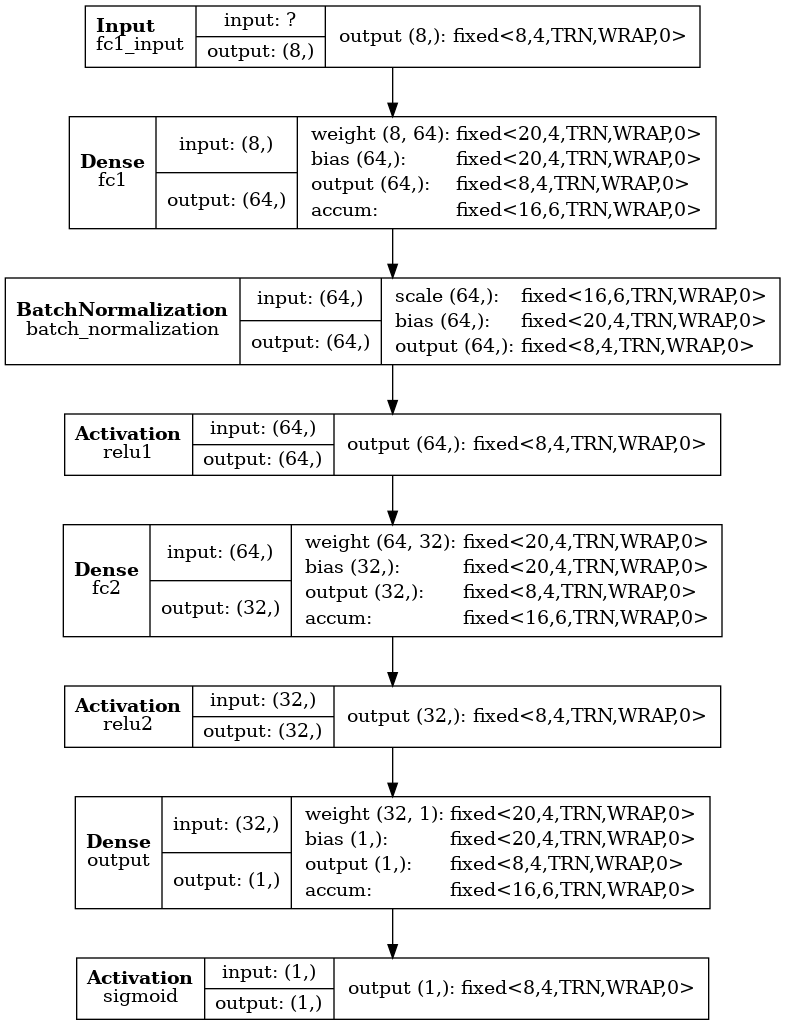

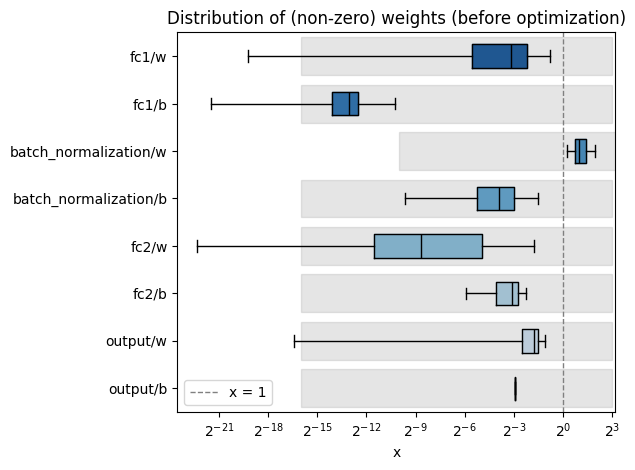

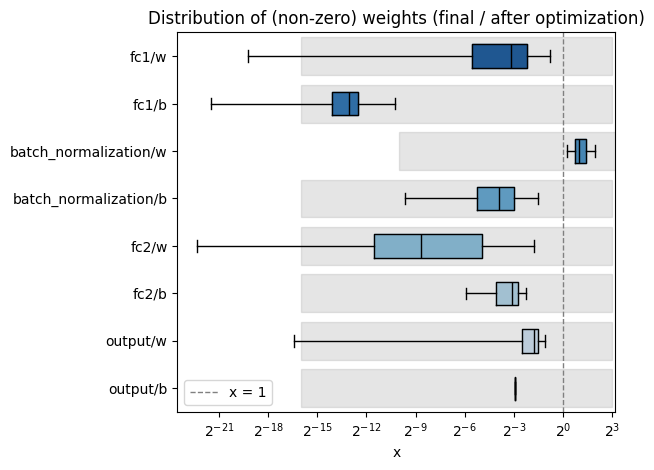

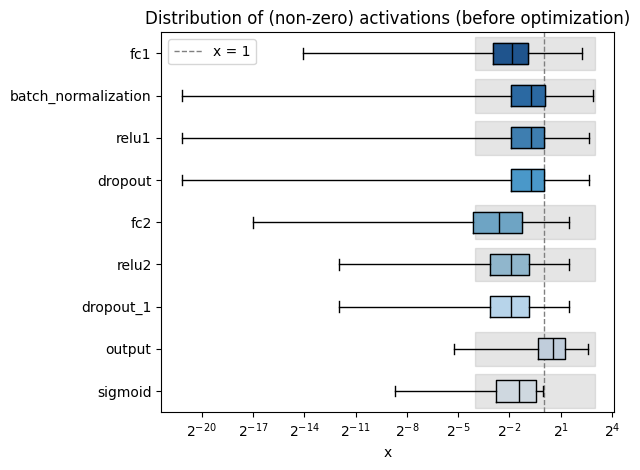

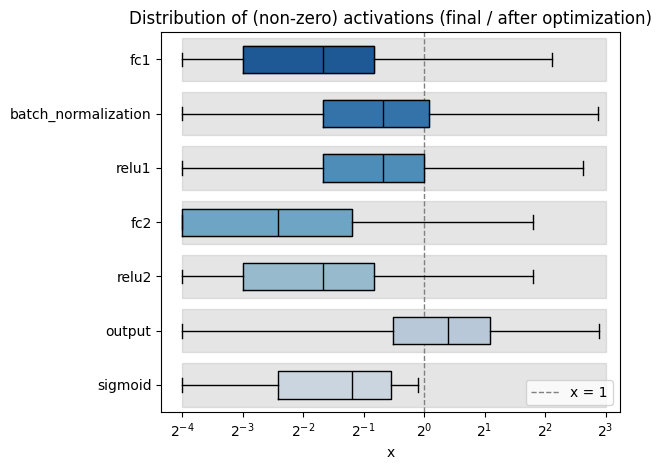

In [5]:
%matplotlib inline
from hls4ml.model.profiling import numerical, get_ymodel_keras
config = hls4ml.utils.config_from_keras_model(model, granularity='name')


# Loop through every layer in the model
for layer in config['LayerName'].keys():
    # Enable tracing for the profiling plots
    config['LayerName'][layer]['Trace'] = True
    
    # Initialize the Precision dictionary for the layer if it doesn't exist
    if 'Precision' not in config['LayerName'][layer]:
        config['LayerName'][layer]['Precision'] = {}

    # Set the precision for Weights and Biases
    config['LayerName'][layer]['Precision']['weight'] = 'ap_fixed<20,4>'
    config['LayerName'][layer]['Precision']['bias'] = 'ap_fixed<20,4>'
    
    # Set the precision for the activations/outputs
    # In hls4ml, the output of a layer is called result
    config['LayerName'][layer]['Precision']['result'] = 'ap_fixed<8,4>'

    
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vitis' ,output_dir='quantized_model_1/hls4ml_prj', part='xcu250-figd2104-2L-e'
)
numerical(model=model, hls_model=hls_model, X=X_test[:1000])
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

In [6]:
hls_model.compile()
hls4ml_pred, hls4ml_trace = hls_model.trace(X_test[:1000])
keras_trace = get_ymodel_keras(model, X_test[:1000])
y_hls = hls_model.predict(X_test)

Recompiling myproject with tracing
5/5 [==============================] - 0s 869us/step
Done taking outputs for Keras model.


In [7]:
print("Keras layer 'fc1', first sample:")
print(keras_trace['fc1'][0])
print("hls4ml layer 'fc1', first sample:")
print(hls4ml_trace['fc1'][0])

Keras layer 'fc1', first sample:
[-0.10682084  0.72081006  0.04541687  0.08827098 -0.06146448  0.06929582
  0.17083474 -0.13597874 -0.15718332 -0.27224755 -0.10469848 -0.262978
 -0.37712705  0.6957337  -0.3125904  -0.05437844  0.2563535   0.1576176
 -0.04139279 -0.00498902  0.0623247  -0.14303827 -0.24518818  0.10292939
  0.12506035 -0.08183396  0.496608   -0.28536877  0.21368082 -0.20777813
 -0.6470788   0.1388541   0.12422872  0.02254546  0.09807201  0.3114882
  0.19679628  0.38271987 -0.03738528  0.13762374 -0.01842641  0.07996446
 -0.24622004 -0.12049452 -0.1765435  -0.33731875  0.91673666  0.0235685
 -0.07582165  0.14226802  0.45236444 -0.0450377  -0.2648906   0.06735948
  0.02602673 -0.40946418  0.25420517 -0.48193145 -0.23129065 -0.04512321
 -0.24915403  0.7489378   0.74394345  0.15000018]
hls4ml layer 'fc1', first sample:
[-0.125   0.6875  0.      0.0625 -0.0625  0.      0.125  -0.1875 -0.1875
 -0.3125 -0.125  -0.3125 -0.4375  0.625  -0.375  -0.0625  0.25    0.125
 -0.0625  0. 

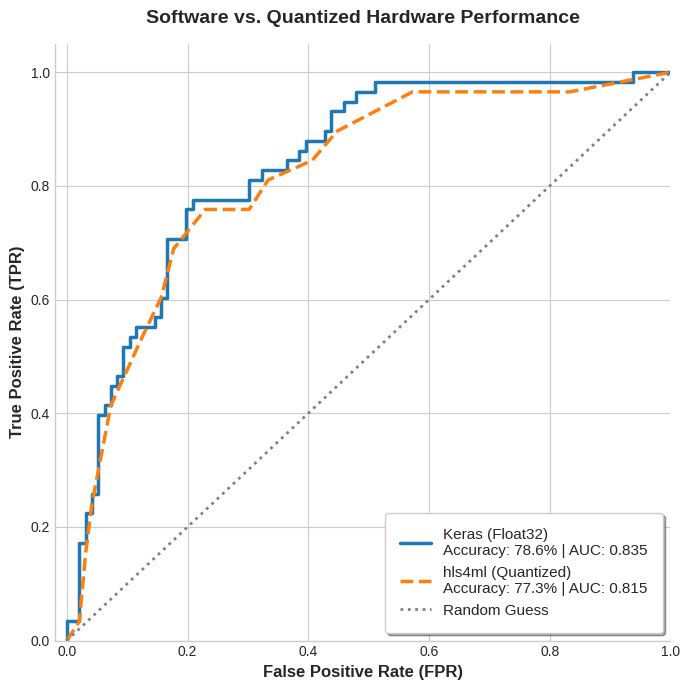

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score

# Generate predictions and calculate accuracies
y_keras_pred = (y_keras > 0.5).astype(int).ravel()
y_hls_pred = (y_hls > 0.5).astype(int).ravel()

acc_keras = accuracy_score(y_test, y_keras_pred)
acc_hls = accuracy_score(y_test, y_hls_pred)

# Calculate ROC and AUC
fpr_keras, tpr_keras, _ = roc_curve(y_test, y_keras.ravel())
roc_auc_keras = auc(fpr_keras, tpr_keras)

fpr_hls, tpr_hls, _ = roc_curve(y_test, y_hls.ravel())
roc_auc_hls = auc(fpr_hls, tpr_hls)

plt.style.use('seaborn-v0_8-whitegrid') 
fig, ax = plt.subplots(figsize=(7, 7))

# Plot Keras
ax.plot(fpr_keras, tpr_keras, color='#1f77b4', linewidth=2.5, 
        label=f"Keras (Float32)\nAccuracy: {acc_keras*100:.1f}% | AUC: {roc_auc_keras:.3f}")

# Plot hls4ml
ax.plot(fpr_hls, tpr_hls, color='#ff7f0e', linewidth=2.5, linestyle='--',
        label=f"hls4ml (Quantized)\nAccuracy: {acc_hls*100:.1f}% | AUC: {roc_auc_hls:.3f}")

# Plot Random Guess Baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=2, label="Random Guess")

ax.set_xlabel("False Positive Rate (FPR)", fontsize=12, fontweight='bold')
ax.set_ylabel("True Positive Rate (TPR)", fontsize=12, fontweight='bold')
ax.set_title("Software vs. Quantized Hardware Performance", fontsize=14, fontweight='bold', pad=15)

# Tweak axes limits
ax.set_xlim([-0.02, 1.0])
ax.set_ylim([0.0, 1.05])

# Add a legend 
ax.legend(loc="lower right", fontsize=11, frameon=True, shadow=True, borderpad=1)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
hls_model.build(csim=False)


****** vitis-run v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:10
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /home/tvangos/Desktop/UTH/CPU_design/src/quantized_model_1/hls4ml_prj/build_prj.tcl -work_dir /home/tvangos/Desktop/UTH/CPU_design/src/quantized_model_1/hls4ml_prj

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW Build 4023990 on Oct 11 2023
  **** IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
  **** SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2023.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2023.2/bin/unwrapped/lnx64.o/vitis_hl

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.647',
  'BestLatency': '9',
  'WorstLatency': '9',
  'IntervalMin': '1',
  'IntervalMax': '1',
  'BRAM_18K': '1',
  'DSP': '1234',
  'FF': '10519',
  'LUT': '96923',
  'URAM': '0',
  'AvailableBRAM_18K': '5376',
  'AvailableDSP': '12288',
  'AvailableFF': '3456000',
  'AvailableLUT': '1728000',
  'AvailableURAM': '1280'}}